# 📊 MODELO AUTOREGRESIVO CON VARIACIONES

## Predecir Cambios (no Niveles Absolutos)
### La Nueva Solución
**Predecir VARIACIÓN_mensual + inercia económica:**

El sentimiento debería predecir **cambios económicos**, no niveles absolutos.

**Modelo:**
```
Δ%_VAB(mes_t) = f(sentimiento(t), VAB(t-1), tendencia_reciente)
```

**Ventajas:**
1. Más realista: Economía tiene inercia (VAB_mes depende de VAB_anterior)
2. Sentimiento modula cambios, no determina nivel absoluto
3. Evita inflación sistemática

### Modelos a Comparar

**MODELO 1 - ARIMA Baseline:**
- VAB 2007-2023 (17 años)
- Solo historia, sin sentimiento

**MODELO 2 - Autoregresivo con Sentimiento:**
- Predice variación % mensual
- Features: sentimiento + VAB histórico
- Itera mes por mes en 2024


**MODELO 3 - GAM:**
- Features: sentimiento + VAB histórico
- Itera mes por mes en 2024

In [ ]:
# =================================================================
# CONFIGURACIÓN INICIAL
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
import os

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Montar Drive
drive.mount('/content/drive')

# CONFIGURACIÓN
path_proyecto = "/content/drive/MyDrive/TitulacionF"

print("=" * 70)
print("  NOTEBOOK 3: MODELO AUTOREGRESIVO CON VARIACIONES")
print("  Predice CAMBIOS (no niveles absolutos)")
print("=" * 70)
print("\n✅ Librerías cargadas")
print(f"📁 Ruta del proyecto: {path_proyecto}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  NOTEBOOK 3: MODELO AUTOREGRESIVO CON VARIACIONES
  Predice CAMBIOS (no niveles absolutos)

✅ Librerías cargadas
📁 Ruta del proyecto: /content/drive/MyDrive/TitulacionF


In [ ]:
# =================================================================
# BLOQUE 1: CARGAR DATOS
# =================================================================

print("\n" + "=" * 70)
print("CARGA DE DATOS")
print("=" * 70)

# VAB completo para baseline
df_vab_completo = pd.read_csv(f"{path_proyecto}/vab_manabi_2007_2023.csv")
print(f"✅ VAB 2007-2023: {len(df_vab_completo)} años")

# VAB calibración
df_vab_calibracion = pd.read_csv(f"{path_proyecto}/vab_manabi_2020_2023.csv")
print(f"✅ VAB 2020-2023: {len(df_vab_calibracion)} años")

# Sentimiento mensual
df_sentimiento = pd.read_csv(f"{path_proyecto}/sentimiento_mensual_2020_2024.csv")
print(f"✅ Sentimiento: {len(df_sentimiento)} meses (2020-2024)")

print("\n" + "=" * 70)


CARGA DE DATOS
✅ VAB 2007-2023: 17 años
✅ VAB 2020-2023: 4 años
✅ Sentimiento: 75 meses (2020-2024)



In [ ]:
# =================================================================
# BLOQUE 2: MODELO BASELINE - ARIMA
# =================================================================

print("\n" + "=" * 70)
print("MODELO 1: BASELINE (ARIMA)")
print("=" * 70)

serie_vab = df_vab_completo['vab_corriente'].values
años_vab = df_vab_completo['año'].values

print(f"\n📊 Serie temporal: {len(serie_vab)} años (2007-2023)")

# Entrenar ARIMA
print("\n🤖 Entrenando ARIMA...")
configuraciones = [(1, 1, 1), (2, 1, 0), (1, 1, 0), (0, 1, 1), (2, 0, 0)]

mejor_aic = float('inf')
mejor_resultado = None
mejor_orden = None

for orden in configuraciones:
    try:
        modelo = ARIMA(serie_vab, order=orden)
        resultado = modelo.fit()
        if resultado.aic < mejor_aic:
            mejor_aic = resultado.aic
            mejor_resultado = resultado
            mejor_orden = orden
        print(f"  ARIMA{orden}: AIC={resultado.aic:.2f}")
    except:
        print(f"  ARIMA{orden}: Falló")

if mejor_resultado:
    print(f"\n✅ Mejor: ARIMA{mejor_orden}, AIC={mejor_aic:.2f}")

    prediccion_vab_2024_arima = mejor_resultado.forecast(steps=1)[0]
    vab_2023 = serie_vab[-1]
    tasa_var_arima = ((prediccion_vab_2024_arima - vab_2023) / vab_2023) * 100

    print(f"\n🔮 PREDICCIÓN 2024:")
    print(f"  VAB: ${prediccion_vab_2024_arima:.2f}M")
    print(f"  Variación: {tasa_var_arima:+.2f}%")

    predicciones_arima = mejor_resultado.fittedvalues
    if len(predicciones_arima) == len(serie_vab):
        valores_reales = serie_vab
    else:
        valores_reales = serie_vab[-len(predicciones_arima):]

    mae_arima = mean_absolute_error(valores_reales, predicciones_arima)
    print(f"  MAE in-sample: ${mae_arima:.2f}M")
else:
    print("\n❌ ARIMA falló")
    prediccion_vab_2024_arima = None

print("\n" + "=" * 70)


MODELO 1: BASELINE (ARIMA)

📊 Serie temporal: 17 años (2007-2023)

🤖 Entrenando ARIMA...
  ARIMA(1, 1, 1): AIC=251.41
  ARIMA(2, 1, 0): AIC=252.14
  ARIMA(1, 1, 0): AIC=250.98
  ARIMA(0, 1, 1): AIC=250.99
  ARIMA(2, 0, 0): AIC=272.19

✅ Mejor: ARIMA(1, 1, 0), AIC=250.98

🔮 PREDICCIÓN 2024:
  VAB: $5884.22M
  Variación: -0.33%
  MAE in-sample: $541.96M



In [ ]:
# =================================================================
# BLOQUE 3: DISTRIBUCIÓN DE VAB MENSUAL
# =================================================================

print("\n" + "=" * 70)
print("DISTRIBUCIÓN MENSUAL DEL VAB (2020-2023)")
print("=" * 70)

print("\n💡 Estrategia: Distribuir VAB anual proporcionalmente al sentimiento")

df_sent_calib = df_sentimiento[df_sentimiento['año'].between(2020, 2023)].copy()

vab_mensual_list = []

for año in range(2020, 2024):
    vab_anual = df_vab_calibracion[df_vab_calibracion['año'] == año]['vab_corriente'].values[0]
    sent_año = df_sent_calib[df_sent_calib['año'] == año].copy()

    if len(sent_año) == 0:
        continue

    # Convertir a escala positiva para distribución
    sent_año['sent_positivo'] = sent_año['sentimiento_promedio'] + 1
    suma_sent_positivo = sent_año['sent_positivo'].sum()
    sent_año['vab_mensual'] = (sent_año['sent_positivo'] / suma_sent_positivo) * vab_anual

    for _, row in sent_año.iterrows():
        vab_mensual_list.append({
            'año': row['año'],
            'mes': row['mes'],
            'año_mes': row['año_mes'],
            'vab_mensual': row['vab_mensual']
        })

    suma_mensual = sent_año['vab_mensual'].sum()
    print(f"  {año}: VAB_anual=${vab_anual:.2f}M, Suma_mensual=${suma_mensual:.2f}M ✓")

df_vab_mensual = pd.DataFrame(vab_mensual_list)
print(f"\n✅ {len(df_vab_mensual)} meses distribuidos")

print("\n" + "=" * 70)


DISTRIBUCIÓN MENSUAL DEL VAB (2020-2023)

💡 Estrategia: Distribuir VAB anual proporcionalmente al sentimiento
  2020: VAB_anual=$4515.50M, Suma_mensual=$4515.50M ✓
  2021: VAB_anual=$4906.40M, Suma_mensual=$4906.40M ✓
  2022: VAB_anual=$5496.60M, Suma_mensual=$5496.60M ✓
  2023: VAB_anual=$5903.50M, Suma_mensual=$5903.50M ✓

✅ 48 meses distribuidos



In [ ]:
# =================================================================
# BLOQUE 4: PREPARAR DATOS CON VARIACIONES Y FEATURES AUTOREGRESIVOS
# =================================================================

print("\n" + "=" * 70)
print("PREPARACIÓN DE DATOS CON VARIACIONES")
print("=" * 70)

# Merge sentimiento con VAB mensual
df_train = df_sent_calib.merge(
    df_vab_mensual[['año_mes', 'vab_mensual']],
    on='año_mes',
    how='inner'
)

# CALCULAR VARIACIÓN PORCENTUAL MENSUAL (TARGET)
df_train = df_train.sort_values('año_mes').reset_index(drop=True)
df_train['vab_variacion_pct'] = df_train['vab_mensual'].pct_change() * 100

# FEATURES AUTOREGRESIVOS (VAB histórico)
df_train['vab_mes_anterior'] = df_train['vab_mensual'].shift(1)
df_train['vab_promedio_3m'] = df_train['vab_mensual'].rolling(3, min_periods=1).mean()
df_train['vab_tendencia_3m'] = df_train['vab_mensual'].diff(3)  # Cambio vs hace 3 meses

# FEATURES DE SENTIMIENTO
feature_cols = [
    'sentimiento_promedio',
    'pct_positivas',
    'pct_negativas',
    'volatilidad_movil_3m',
    'num_noticias',
    # Features autoregresivos:
    'vab_mes_anterior',
    'vab_promedio_3m'
]

# Verificar disponibilidad
features_disponibles = [col for col in feature_cols if col in df_train.columns]
feature_cols = features_disponibles

print(f"\n📊 CONFIGURACIÓN:")
print(f"  Target: vab_variacion_pct (cambio % mensual)")
print(f"  Features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"    • {col}")

# Eliminar NaN (primera fila por pct_change)
df_train_clean = df_train.dropna(subset=['vab_variacion_pct'] + feature_cols)

X_train = df_train_clean[feature_cols].values
y_train = df_train_clean['vab_variacion_pct'].values

print(f"\n📊 Datos finales:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  Ratio obs/features: {len(y_train)}/{len(feature_cols)} = {len(y_train)/len(feature_cols):.1f}")

print("\n" + "=" * 70)


PREPARACIÓN DE DATOS CON VARIACIONES

📊 CONFIGURACIÓN:
  Target: vab_variacion_pct (cambio % mensual)
  Features (7):
    • sentimiento_promedio
    • pct_positivas
    • pct_negativas
    • volatilidad_movil_3m
    • num_noticias
    • vab_mes_anterior
    • vab_promedio_3m

📊 Datos finales:
  X_train: (47, 7)
  y_train: (47,)
  Ratio obs/features: 47/7 = 6.7




ENTRENAMIENTO DEL MODELO

🎯 Modelo: Ridge Regression
   Target: Variación % mensual del VAB

🔍 Buscando mejor regularización...
  Alpha=  0.1: R²=0.9080
  Alpha=  1.0: R²=0.8982
  Alpha= 10.0: R²=0.8966
  Alpha= 50.0: R²=0.8963

✅ Mejor: alpha=0.1

📊 MÉTRICAS:
  MAE:  2.44% (variación mensual)
  RMSE: 2.99%
  R²:   0.9080

📊 IMPORTANCIA:
             Feature  Coeficiente
volatilidad_movil_3m    14.827583
       pct_positivas     0.422925
       pct_negativas    -0.406033
    vab_mes_anterior    -0.293045
     vab_promedio_3m     0.226348
        num_noticias     0.044651
sentimiento_promedio    -0.002308


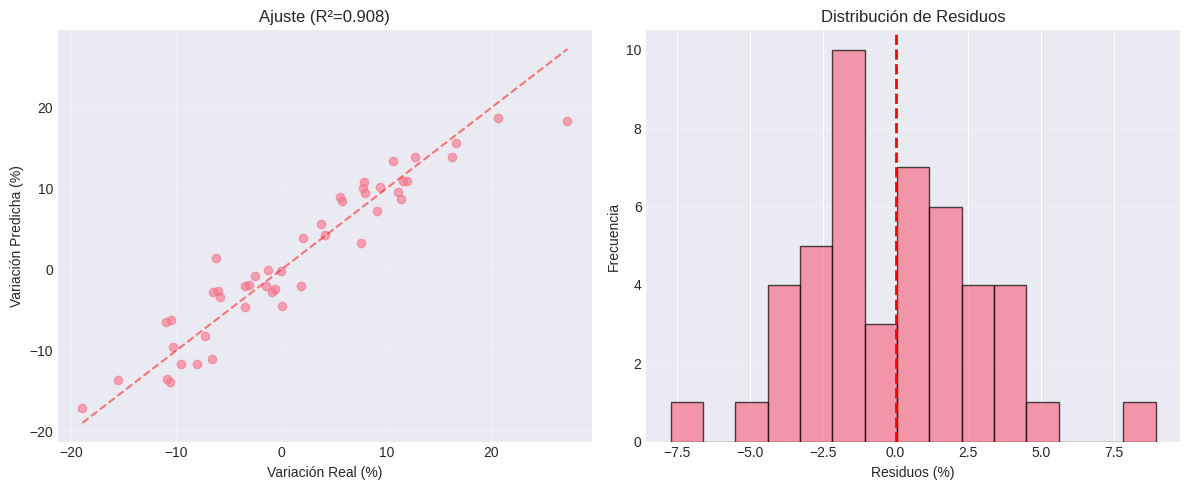

In [ ]:
# =================================================================
# BLOQUE 5: ENTRENAR MODELO DE VARIACIONES
# =================================================================

print("\n" + "=" * 70)
print("ENTRENAMIENTO DEL MODELO")
print("=" * 70)

print("\n🎯 Modelo: Ridge Regression")
print("   Target: Variación % mensual del VAB")

# Probar diferentes alphas
alphas = [0.1, 1.0, 10.0, 50.0]
mejor_alpha = None
mejor_modelo = None
mejor_r2 = -np.inf

print("\n🔍 Buscando mejor regularización...")
for alpha in alphas:
    modelo = Ridge(alpha=alpha)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_train)
    r2 = r2_score(y_train, y_pred)
    print(f"  Alpha={alpha:>5.1f}: R²={r2:.4f}")

    if r2 > mejor_r2:
        mejor_r2 = r2
        mejor_alpha = alpha
        mejor_modelo = modelo

print(f"\n✅ Mejor: alpha={mejor_alpha}")

modelo_variacion = mejor_modelo
y_pred_train = modelo_variacion.predict(X_train)

# Métricas
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print(f"\n📊 MÉTRICAS:")
print(f"  MAE:  {mae_train:.2f}% (variación mensual)")
print(f"  RMSE: {rmse_train:.2f}%")
print(f"  R²:   {r2_train:.4f}")

# Importancia
importancias = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': modelo_variacion.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\n📊 IMPORTANCIA:")
print(importancias.to_string(index=False))

# Visualización
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.6)
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
plt.xlabel('Variación Real (%)')
plt.ylabel('Variación Predicha (%)')
plt.title(f'Ajuste (R²={r2_train:.3f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuos = y_train - y_pred_train
plt.hist(residuos, bins=15, alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Residuos (%)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)

In [ ]:
# =================================================================
# BLOQUE 7 (NUEVO): ENTRENAMIENTO GAM
# =================================================================

print("\n" + "=" * 70)
print("MODELO 3: GAM - GENERALIZED ADDITIVE MODEL")
print("=" * 70)

# Instalar pygam si no está disponible
try:
    from pygam import LinearGAM, s
    print("pygam disponible")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pygam", "-q"])
    from pygam import LinearGAM, s

print("\nEntrenando GAM...")
print("   Target: Variación % mensual del VAB")
print("   Features: 7 splines suavizados (uno por variable)")
print("   Ventaja: Captura relaciones no lineales entre sentimiento y VAB")

# GAM con un spline por cada feature
# s(i) = spline suavizado para la feature en posición i
gam = LinearGAM(
    s(0) +  # sentimiento_promedio
    s(1) +  # pct_positivas
    s(2) +  # pct_negativas
    s(3) +  # volatilidad_movil_3m
    s(4) +  # num_noticias
    s(5) +  # vab_mes_anterior
    s(6)    # vab_promedio_3m
)

gam.fit(X_train, y_train)

# Métricas en entrenamiento
y_pred_gam_train = gam.predict(X_train)
r2_gam   = r2_score(y_train, y_pred_gam_train)
mae_gam  = mean_absolute_error(y_train, y_pred_gam_train)
rmse_gam = np.sqrt(mean_squared_error(y_train, y_pred_gam_train))

print(f"\nMétricas en entrenamiento (2020-2023):")
print(f"  R²   = {r2_gam:.4f}")
print(f"  MAE  = {mae_gam:.4f}%")
print(f"  RMSE = {rmse_gam:.4f}%")

# Comparar con Ridge en entrenamiento
print(f"\nComparación en entrenamiento:")
print(f"  {'Modelo':<30} {'R²':<12} {'MAE':<12} {'RMSE':<12}")
print(f"  {'-'*66}")
print(f"  {'Ridge (alpha=0.1)':<30} {mejor_r2:<12.4f} {mean_absolute_error(y_train, modelo_variacion.predict(X_train)):<12.4f} {np.sqrt(mean_squared_error(y_train, modelo_variacion.predict(X_train))):<12.4f}")
print(f"  {'GAM (LinearGAM)':<30} {r2_gam:<12.4f} {mae_gam:<12.4f} {rmse_gam:<12.4f}")

print("\n" + "=" * 70)



MODELO 3: GAM - GENERALIZED ADDITIVE MODEL
pygam disponible

Entrenando GAM...
   Target: Variación % mensual del VAB
   Features: 7 splines suavizados (uno por variable)
   Ventaja: Captura relaciones no lineales entre sentimiento y VAB

Métricas en entrenamiento (2020-2023):
  R²   = 0.4471
  MAE  = 5.3875%
  RMSE = 7.3263%

Comparación en entrenamiento:
  Modelo                         R²           MAE          RMSE        
  ------------------------------------------------------------------
  Ridge (alpha=0.1)              0.9080       2.4415       2.9884      
  GAM (LinearGAM)                0.4471       5.3875       7.3263      




PREDICCIÓN VAB 2024 (ITERATIVA)

 Metodologia:
  1. Partir de VAB_dic_2023 (último conocido)
  2. Para cada mes 2024:
     a. Predecir variación % usando sentimiento + VAB anterior
     b. Calcular VAB_mes = VAB_anterior × (1 + variacion/100)
     c. Usar este VAB como 'anterior' para el siguiente mes
  3. Sumar los 12 meses → VAB total 2024

📊 Datos 2024: 12 meses

🔮 Predicciones mes por mes:
----------------------------------------------------------------------
  2024-01: Δ= -6.34% → VAB=$ 460.78M
  2024-02: Δ= -3.39% → VAB=$ 445.17M
  2024-03: Δ=+10.47% → VAB=$ 491.79M
  2024-04: Δ=-10.09% → VAB=$ 442.16M
  2024-05: Δ= +7.87% → VAB=$ 476.96M
  2024-06: Δ= -0.76% → VAB=$ 473.36M
  2024-07: Δ= +1.94% → VAB=$ 482.52M
  2024-08: Δ= -1.35% → VAB=$ 476.00M
  2024-09: Δ= +3.73% → VAB=$ 493.77M
  2024-10: Δ= -0.32% → VAB=$ 492.17M
  2024-11: Δ= +1.06% → VAB=$ 497.38M
  2024-12: Δ= +3.17% → VAB=$ 513.12M
----------------------------------------------------------------------

🔮 PREDICCIÓN FI

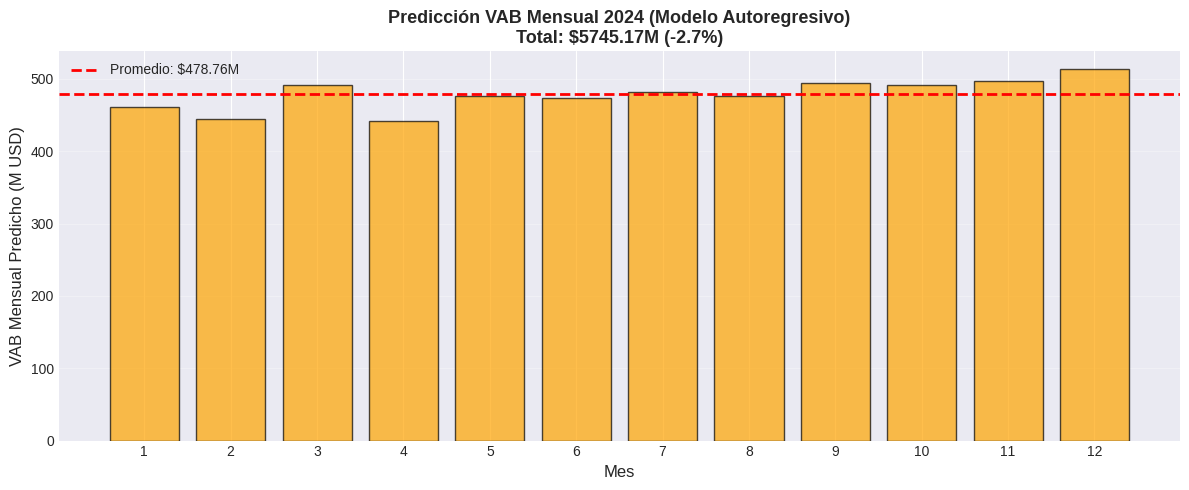

In [ ]:
# =================================================================
# BLOQUE 6: PREDICCIÓN 2024 (ITERATIVA MES POR MES)
# =================================================================

print("\n" + "=" * 70)
print("PREDICCIÓN VAB 2024 (ITERATIVA)")
print("=" * 70)

print("\n Metodologia:")
print("  1. Partir de VAB_dic_2023 (último conocido)")
print("  2. Para cada mes 2024:")
print("     a. Predecir variación % usando sentimiento + VAB anterior")
print("     b. Calcular VAB_mes = VAB_anterior × (1 + variacion/100)")
print("     c. Usar este VAB como 'anterior' para el siguiente mes")
print("  3. Sumar los 12 meses → VAB total 2024")

# Sentimiento 2024
df_sent_2024 = df_sentimiento[df_sentimiento['año'] == 2024].copy()
df_sent_2024 = df_sent_2024.sort_values('mes').reset_index(drop=True)

print(f"\n📊 Datos 2024: {len(df_sent_2024)} meses")

if len(df_sent_2024) > 0:
    # Inicializar con último VAB conocido (diciembre 2023)
    # Aproximamos dic_2023 como 1/12 del VAB anual 2023
    vab_2023_anual = df_vab_calibracion[df_vab_calibracion['año'] == 2023]['vab_corriente'].values[0]
    vab_actual = vab_2023_anual / 12  # Aproximación inicial
    vab_promedio_3m = vab_actual  # Inicializar

    predicciones_2024 = []

    print("\n🔮 Predicciones mes por mes:")
    print("-" * 70)

    for idx, row in df_sent_2024.iterrows():
        # Preparar features
        features_mes = {
            'sentimiento_promedio': row.get('sentimiento_promedio', 0),
            'pct_positivas': row.get('pct_positivas', 0),
            'pct_negativas': row.get('pct_negativas', 0),
            'volatilidad_movil_3m': row.get('volatilidad_movil_3m', 0),
            'num_noticias': row.get('num_noticias', 0),
            'vab_mes_anterior': vab_actual,
            'vab_promedio_3m': vab_promedio_3m
        }


        # Crear array en orden correcto
        X_mes = np.array([[features_mes[col] for col in feature_cols]])

        # Predecir variación %
        variacion_pred = modelo_variacion.predict(X_mes)[0]

        # Calcular nuevo VAB
        vab_nuevo = vab_actual * (1 + variacion_pred / 100)

        predicciones_2024.append({
            'año_mes': row['año_mes'],
            'mes': row['mes'],
            'vab_predicho': vab_nuevo,
            'variacion_pred': variacion_pred,
            'vab_anterior': vab_actual
        })

        print(f"  {row['año_mes']}: Δ={variacion_pred:+6.2f}% → VAB=${vab_nuevo:7.2f}M")

        # Actualizar para siguiente iteración
        vab_actual = vab_nuevo
        # Actualizar promedio 3m (ventana deslizante simplificada)
        if idx >= 2:
            ultimos_3 = [p['vab_predicho'] for p in predicciones_2024[-3:]]
            vab_promedio_3m = np.mean(ultimos_3)
        else:
            vab_promedio_3m = vab_nuevo

    # Convertir a DataFrame
    df_pred_2024 = pd.DataFrame(predicciones_2024)

    # Sumar para obtener VAB total 2024
    vab_2024_sentimiento = df_pred_2024['vab_predicho'].sum()
    tasa_var_2024_sentimiento = ((vab_2024_sentimiento - vab_2023_anual) / vab_2023_anual) * 100

    print("-" * 70)
    print(f"\n🔮 PREDICCIÓN FINAL 2024:")
    print(f"  VAB total: ${vab_2024_sentimiento:.2f}M")
    print(f"  Variación vs 2023: {tasa_var_2024_sentimiento:+.2f}%")
    print(f"  (Base 2023: ${vab_2023_anual:.2f}M)")

    # Visualización
    plt.figure(figsize=(12, 5))

    meses = df_pred_2024['mes'].values
    vab_mensual = df_pred_2024['vab_predicho'].values

    plt.bar(meses, vab_mensual, alpha=0.7, color='orange', edgecolor='black')
    plt.axhline(y=vab_mensual.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Promedio: ${vab_mensual.mean():.2f}M')
    plt.xlabel('Mes', fontsize=12)
    plt.ylabel('VAB Mensual Predicho (M USD)', fontsize=12)
    plt.title(f'Predicción VAB Mensual 2024 (Modelo Autoregresivo)\nTotal: ${vab_2024_sentimiento:.2f}M ({tasa_var_2024_sentimiento:+.1f}%)',
              fontweight='bold', fontsize=13)
    plt.xticks(meses)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

else:
    print("\n⚠️ No hay datos 2024")
    vab_2024_sentimiento = None

print("\n" + "=" * 70)


COMPARACIÓN DE MODELOS

📊 PREDICCIONES 2024:
Modelo                                   VAB 2024        Variación      
ARIMA Baseline                           $5884.22        -0.33%
Autoregresivo + Sentimiento              $5745.17        -2.68%

Diferencia entre modelos: $139.05M


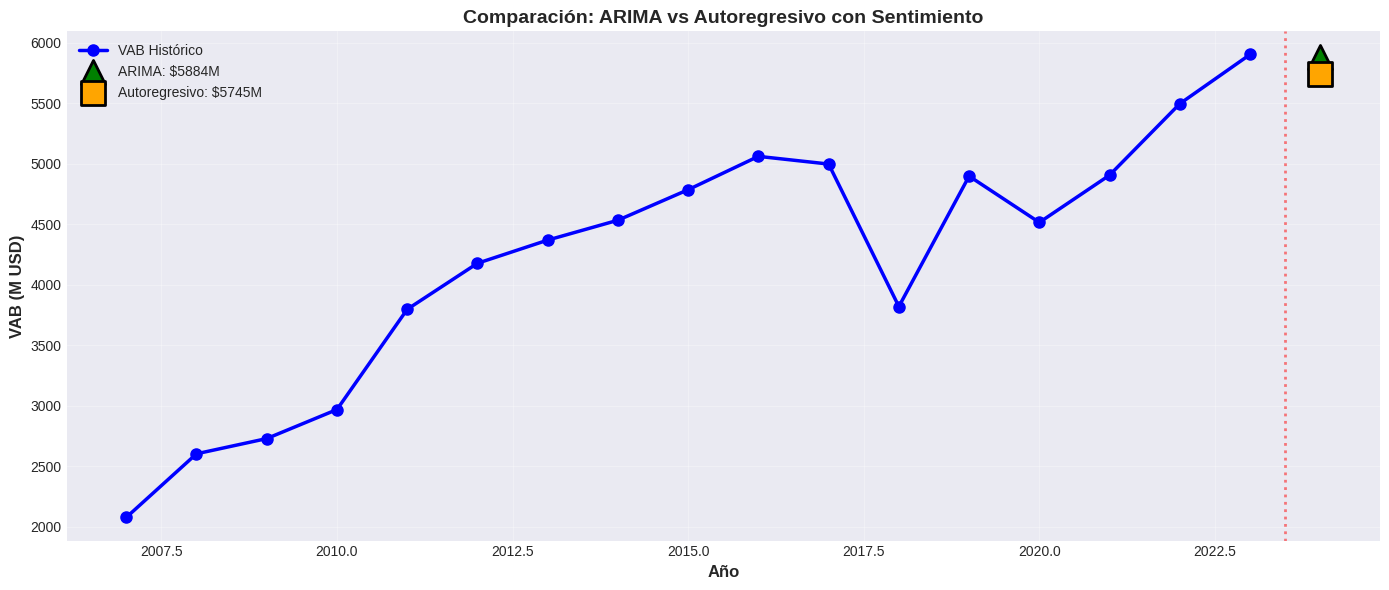

In [ ]:
# =================================================================
# BLOQUE 7: COMPARACIÓN CON ARIMA
# =================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)

if prediccion_vab_2024_arima and vab_2024_sentimiento:
    print("\n📊 PREDICCIONES 2024:")
    print("=" * 70)
    print(f"{'Modelo':<40} {'VAB 2024':<15} {'Variación':<15}")
    print("=" * 70)
    print(f"{'ARIMA Baseline':<40} ${prediccion_vab_2024_arima:<14.2f} {tasa_var_arima:+.2f}%")
    print(f"{'Autoregresivo + Sentimiento':<40} ${vab_2024_sentimiento:<14.2f} {tasa_var_2024_sentimiento:+.2f}%")
    print("=" * 70)

    dif = abs(vab_2024_sentimiento - prediccion_vab_2024_arima)
    print(f"\nDiferencia entre modelos: ${dif:.2f}M")

    # Visualización
    plt.figure(figsize=(14, 6))

    plt.plot(años_vab, serie_vab, 'o-',
             label='VAB Histórico', linewidth=2.5, markersize=8, color='blue')

    plt.scatter([2024], [prediccion_vab_2024_arima],
                color='green', s=300, marker='^', zorder=5, edgecolors='black', linewidths=2,
                label=f'ARIMA: ${prediccion_vab_2024_arima:.0f}M')

    plt.scatter([2024], [vab_2024_sentimiento],
                color='orange', s=300, marker='s', zorder=5, edgecolors='black', linewidths=2,
                label=f'Autoregresivo: ${vab_2024_sentimiento:.0f}M')

    plt.axvline(x=2023.5, color='red', linestyle=':', alpha=0.5, linewidth=2)
    plt.xlabel('Año', fontsize=12, fontweight='bold')
    plt.ylabel('VAB (M USD)', fontsize=12, fontweight='bold')
    plt.title('Comparación: ARIMA vs Autoregresivo con Sentimiento',
              fontweight='bold', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)


VALIDACIÓN CON VAB REAL 2024

✅ VAB Real 2024: $5768.40M
   Variación real: -2.29%

📊 RESULTADOS:
Modelo                                   Predicción      Error Abs       Error %         Error Tasa     
Real 2024                                $5768.40        -              -              -             
ARIMA                                    $5884.22        $115.82         2.01          % 1.96          pp
Autoregresivo + Sentimiento              $5745.17        $23.23          0.40          % 0.39          pp

🏆 RESULTADO:
  ✅ GANADOR: Modelo Autoregresivo + Sentimiento
  📈 Mejora: 79.9% menor error que ARIMA


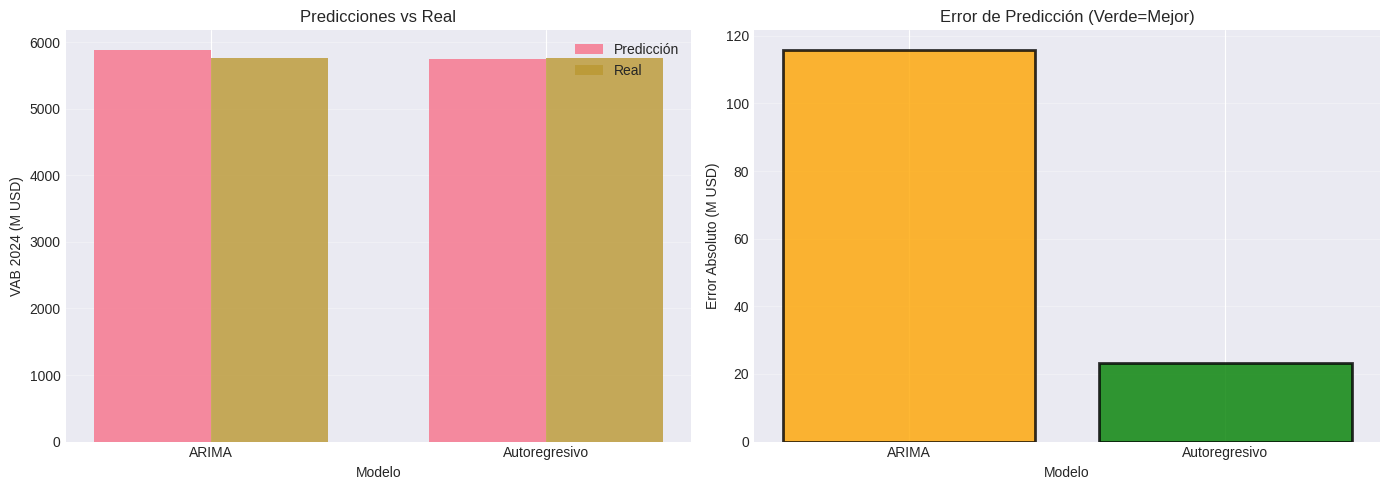

In [ ]:
# =================================================================
# BLOQUE 8: VALIDACIÓN CON VAB REAL 2024
# =================================================================

print("\n" + "=" * 70)
print("VALIDACIÓN CON VAB REAL 2024")
print("=" * 70)

vab_real_2024 = 5768.4  # Millones USD

if vab_real_2024:
    vab_2023_ref = df_vab_calibracion[df_vab_calibracion['año']==2023]['vab_corriente'].values[0]
    tasa_var_real = ((vab_real_2024 - vab_2023_ref) / vab_2023_ref) * 100

    print(f"\n✅ VAB Real 2024: ${vab_real_2024:.2f}M")
    print(f"   Variación real: {tasa_var_real:+.2f}%")

    # Errores
    if prediccion_vab_2024_arima:
        error_arima = abs(prediccion_vab_2024_arima - vab_real_2024)
        error_pct_arima = (error_arima / vab_real_2024) * 100
        error_tasa_arima = abs(tasa_var_arima - tasa_var_real)

    if vab_2024_sentimiento:
        error_sent = abs(vab_2024_sentimiento - vab_real_2024)
        error_pct_sent = (error_sent / vab_real_2024) * 100
        error_tasa_sent = abs(tasa_var_2024_sentimiento - tasa_var_real)

    print("\n📊 RESULTADOS:")
    print("=" * 90)
    print(f"{'Modelo':<40} {'Predicción':<15} {'Error Abs':<15} {'Error %':<15} {'Error Tasa':<15}")
    print("=" * 90)
    print(f"{'Real 2024':<40} ${vab_real_2024:<14.2f} {'-':<14} {'-':<14} {'-':<14}")

    if prediccion_vab_2024_arima:
        print(f"{'ARIMA':<40} ${prediccion_vab_2024_arima:<14.2f} ${error_arima:<14.2f} {error_pct_arima:<14.2f}% {error_tasa_arima:<14.2f}pp")

    if vab_2024_sentimiento:
        print(f"{'Autoregresivo + Sentimiento':<40} ${vab_2024_sentimiento:<14.2f} ${error_sent:<14.2f} {error_pct_sent:<14.2f}% {error_tasa_sent:<14.2f}pp")

    print("=" * 90)

    # Ganador
    if error_arima and error_sent:
        print("\n🏆 RESULTADO:")
        if error_sent < error_arima:
            mejora = ((error_arima - error_sent) / error_arima) * 100
            print(f"  ✅ GANADOR: Modelo Autoregresivo + Sentimiento")
            print(f"  📈 Mejora: {mejora:.1f}% menor error que ARIMA")

        else:
            dif = ((error_sent - error_arima) / error_arima) * 100
            print(f"  ⚠️ GANADOR: ARIMA Baseline")
            print(f"  📊 ARIMA tuvo {dif:.1f}% menor error")


    # Visualización
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    modelos = []
    predicciones = []

    if prediccion_vab_2024_arima:
        modelos.append('ARIMA')
        predicciones.append(prediccion_vab_2024_arima)
    if vab_2024_sentimiento:
        modelos.append('Autoregresivo')
        predicciones.append(vab_2024_sentimiento)

    x = np.arange(len(modelos))
    w = 0.35
    plt.bar(x - w/2, predicciones, w, label='Predicción', alpha=0.8)
    plt.bar(x + w/2, [vab_real_2024]*len(modelos), w, label='Real', alpha=0.8)
    plt.xlabel('Modelo')
    plt.ylabel('VAB 2024 (M USD)')
    plt.title('Predicciones vs Real')
    plt.xticks(x, modelos)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    plt.subplot(1, 2, 2)
    errores = []
    if error_arima:
        errores.append(error_arima)
    if error_sent:
        errores.append(error_sent)

    cols = ['green' if e == min(errores) else 'orange' for e in errores]
    plt.bar(modelos, errores, alpha=0.8, color=cols, edgecolor='black', linewidth=2)
    plt.xlabel('Modelo')
    plt.ylabel('Error Absoluto (M USD)')
    plt.title('Error de Predicción (Verde=Mejor)')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)


PREDICCIÓN VAB 2024 - GAM (ITERATIVA MES POR MES)

Metodología idéntica a Ridge:
  1. Partir de VAB_dic_2023
  2. Predecir variación % con GAM para cada mes 2024
  3. Acumular mes a mes

Predicciones mes por mes:
----------------------------------------------------------------------
  2024-01: Δ= -4.75% → VAB=$ 468.60M
  2024-02: Δ= -1.68% → VAB=$ 460.72M
  2024-03: Δ= +3.84% → VAB=$ 478.40M
  2024-04: Δ= -0.40% → VAB=$ 476.50M
  2024-05: Δ= -2.95% → VAB=$ 462.43M
  2024-06: Δ= -0.46% → VAB=$ 460.28M
  2024-07: Δ= +3.81% → VAB=$ 477.80M
  2024-08: Δ= +1.08% → VAB=$ 482.97M
  2024-09: Δ= +2.18% → VAB=$ 493.48M
  2024-10: Δ= +2.27% → VAB=$ 504.67M
  2024-11: Δ= +0.72% → VAB=$ 508.31M
  2024-12: Δ= +6.77% → VAB=$ 542.74M
----------------------------------------------------------------------

PREDICCIÓN FINAL GAM 2024:
  VAB total: $5816.91M
  Variación vs 2023: -1.47%


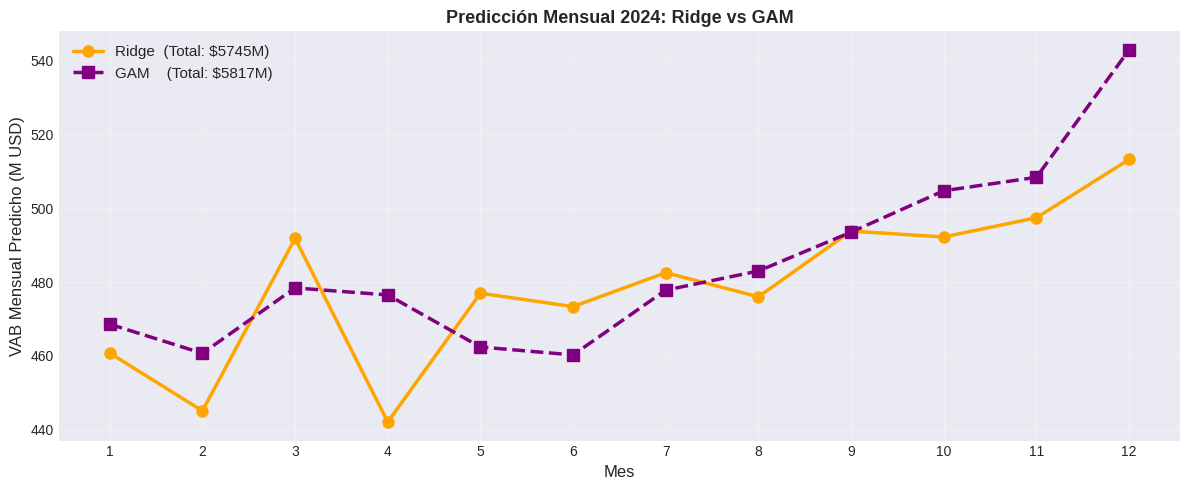

In [ ]:
# =================================================================
# BLOQUE 8 (NUEVO): PREDICCIÓN 2024 CON GAM (ITERATIVA)
# =================================================================

print("\n" + "=" * 70)
print("PREDICCIÓN VAB 2024 - GAM (ITERATIVA MES POR MES)")
print("=" * 70)

print("\nMetodología idéntica a Ridge:")
print("  1. Partir de VAB_dic_2023")
print("  2. Predecir variación % con GAM para cada mes 2024")
print("  3. Acumular mes a mes")

if len(df_sent_2024) > 0:
    vab_actual_gam = vab_2023_anual / 12
    vab_promedio_3m_gam = vab_actual_gam
    predicciones_2024_gam = []

    print("\nPredicciones mes por mes:")
    print("-" * 70)

    for idx, row in df_sent_2024.iterrows():
        features_mes = {
            'sentimiento_promedio': row.get('sentimiento_promedio', 0),
            'pct_positivas':        row.get('pct_positivas', 0),
            'pct_negativas':        row.get('pct_negativas', 0),
            'volatilidad_movil_3m': row.get('volatilidad_movil_3m', 0),
            'num_noticias':         row.get('num_noticias', 0),
            'vab_mes_anterior':     vab_actual_gam,
            'vab_promedio_3m':      vab_promedio_3m_gam
        }

        X_mes_gam = np.array([[features_mes[col] for col in feature_cols]])
        variacion_gam = gam.predict(X_mes_gam)[0]
        vab_nuevo_gam = vab_actual_gam * (1 + variacion_gam / 100)

        predicciones_2024_gam.append({
            'año_mes':      row['año_mes'],
            'mes':          row['mes'],
            'vab_predicho': vab_nuevo_gam,
            'variacion_pred': variacion_gam
        })

        print(f"  {row['año_mes']}: Δ={variacion_gam:+6.2f}% → VAB=${vab_nuevo_gam:7.2f}M")

        vab_actual_gam = vab_nuevo_gam
        if idx >= 2:
            vab_promedio_3m_gam = np.mean([p['vab_predicho'] for p in predicciones_2024_gam[-3:]])
        else:
            vab_promedio_3m_gam = vab_nuevo_gam

    df_pred_2024_gam = pd.DataFrame(predicciones_2024_gam)
    vab_2024_gam = df_pred_2024_gam['vab_predicho'].sum()
    tasa_var_2024_gam = ((vab_2024_gam - vab_2023_anual) / vab_2023_anual) * 100

    print("-" * 70)
    print(f"\nPREDICCIÓN FINAL GAM 2024:")
    print(f"  VAB total: ${vab_2024_gam:.2f}M")
    print(f"  Variación vs 2023: {tasa_var_2024_gam:+.2f}%")

    # Gráfico comparativo Ridge vs GAM mes a mes
    plt.figure(figsize=(12, 5))
    meses = df_pred_2024['mes'].values
    plt.plot(meses, df_pred_2024['vab_predicho'].values,
             'o-', color='orange', linewidth=2.5, markersize=8, label=f'Ridge  (Total: ${vab_2024_sentimiento:.0f}M)')
    plt.plot(meses, df_pred_2024_gam['vab_predicho'].values,
             's--', color='purple', linewidth=2.5, markersize=8, label=f'GAM    (Total: ${vab_2024_gam:.0f}M)')
    plt.xlabel('Mes', fontsize=12)
    plt.ylabel('VAB Mensual Predicho (M USD)', fontsize=12)
    plt.title('Predicción Mensual 2024: Ridge vs GAM', fontweight='bold', fontsize=13)
    plt.xticks(meses)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("\nNo hay datos 2024 disponibles")
    vab_2024_gam = None

print("\n" + "=" * 70)


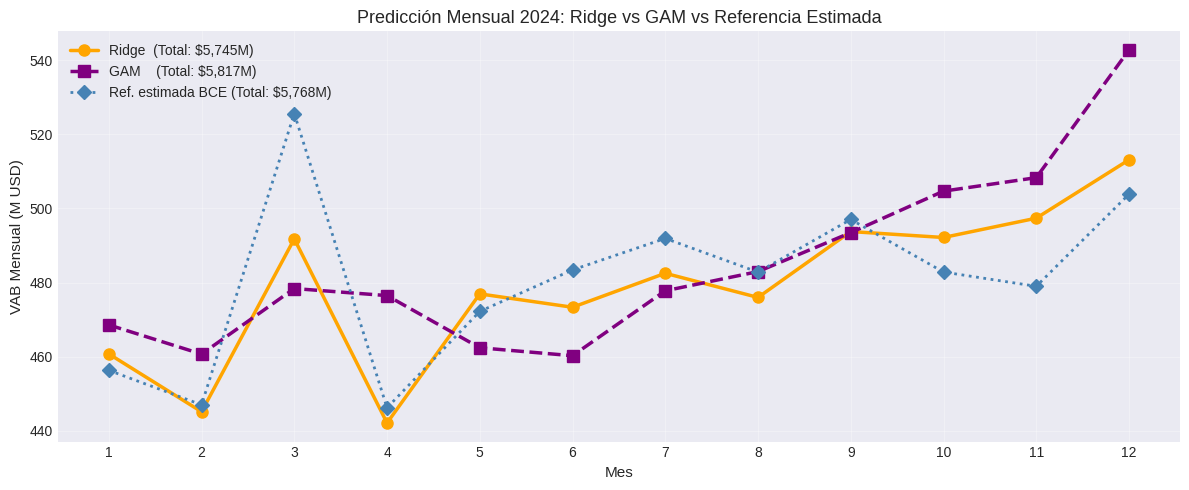

Referencia total: $5,768.40M (debe ser ~5768.4M)


In [ ]:
# =================================================================
# FIGURA MENSUAL 2024 CON REFERENCIA DISTRIBUIDA POR SENTIMIENTO
# =================================================================

VAB_REAL_2024 = 5768.40

sent_2024 = df_sentimiento[df_sentimiento['año'] == 2024].copy()
sent_2024 = sent_2024.sort_values('mes').reset_index(drop=True)

# Distribución del VAB real por sentimiento mensual
offset = abs(sent_2024['sentimiento_promedio'].min()) + 1
sent_2024['peso'] = sent_2024['sentimiento_promedio'] + offset
sent_2024['peso'] = sent_2024['peso'] / sent_2024['peso'].sum()
sent_2024['vab_ref'] = VAB_REAL_2024 * sent_2024['peso']

meses   = sent_2024['mes'].values
vab_ref = sent_2024['vab_ref'].values

df_r = pd.DataFrame(predicciones_2024)
df_g = df_pred_2024_gam.copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(meses, df_r['vab_predicho'], 'o-', color='orange', linewidth=2.5,
        markersize=8, label=f'Ridge  (Total: ${df_r["vab_predicho"].sum():,.0f}M)')
ax.plot(meses, df_g['vab_predicho'], 's--', color='purple', linewidth=2.5,
        markersize=8, label=f'GAM    (Total: ${df_g["vab_predicho"].sum():,.0f}M)')
ax.plot(meses, vab_ref, 'D:', color='steelblue', linewidth=2,
        markersize=7, label=f'Ref. estimada BCE (Total: ${vab_ref.sum():,.0f}M)')

ax.set_title('Predicción Mensual 2024: Ridge vs GAM vs Referencia Estimada', fontsize=13)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('VAB Mensual (M USD)', fontsize=11)
ax.set_xticks(meses)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figura_mensual_2024_con_referencia.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Referencia total: ${vab_ref.sum():,.2f}M (debe ser ~{VAB_REAL_2024}M)")


COMPARACIÓN DE LOS TRES MODELOS - PREDICCIÓN 2024

Predicciones anuales 2024:
  Modelo                                  VAB 2024     Variación
  ARIMA Baseline                      $    5884.22        -0.33%
  Ridge + Sentimiento                 $    5745.17        -2.68%
  GAM + Sentimiento                   $    5816.91        -1.47%


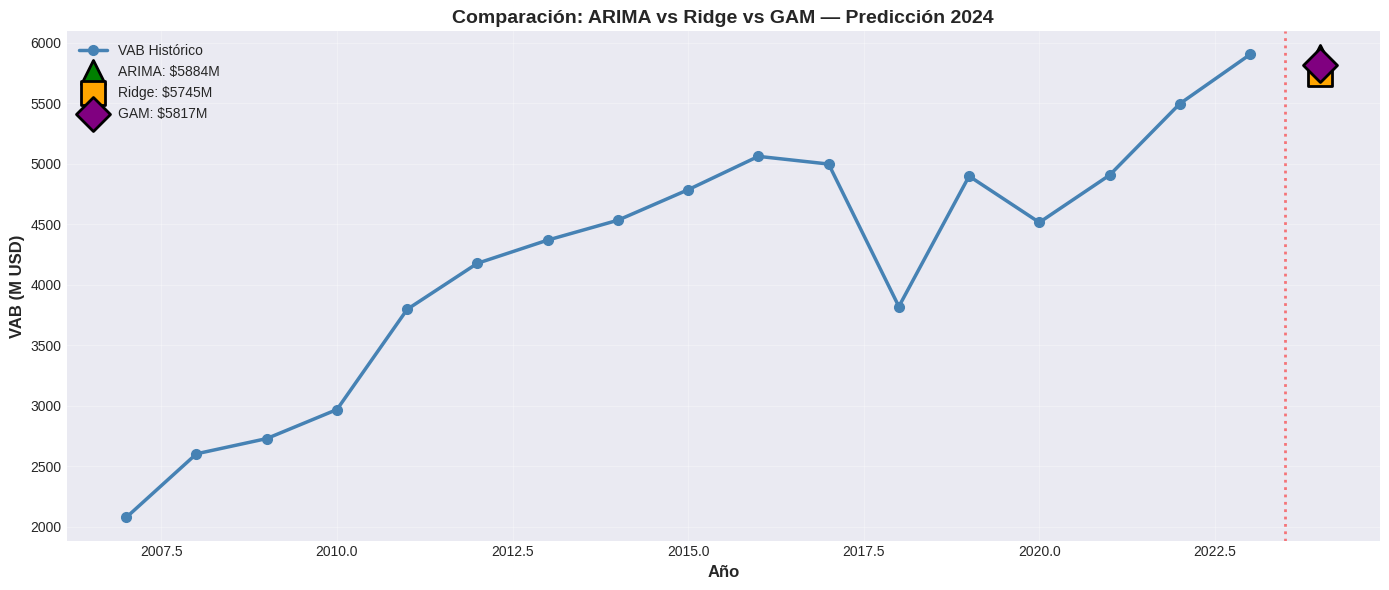

In [ ]:
# =================================================================
# BLOQUE 9 (NUEVO): COMPARACIÓN ARIMA vs RIDGE vs GAM
# =================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE LOS TRES MODELOS - PREDICCIÓN 2024")
print("=" * 70)

if prediccion_vab_2024_arima and vab_2024_sentimiento and vab_2024_gam:
    print("\nPredicciones anuales 2024:")
    print("=" * 70)
    print(f"  {'Modelo':<35} {'VAB 2024':>12}  {'Variación':>12}")
    print("=" * 70)
    print(f"  {'ARIMA Baseline':<35} ${prediccion_vab_2024_arima:>11.2f}  {tasa_var_arima:>+11.2f}%")
    print(f"  {'Ridge + Sentimiento':<35} ${vab_2024_sentimiento:>11.2f}  {tasa_var_2024_sentimiento:>+11.2f}%")
    print(f"  {'GAM + Sentimiento':<35} ${vab_2024_gam:>11.2f}  {tasa_var_2024_gam:>+11.2f}%")
    print("=" * 70)

    # Gráfico: histórico + tres predicciones
    plt.figure(figsize=(14, 6))

    plt.plot(años_vab, serie_vab, 'o-',
             label='VAB Histórico', linewidth=2.5, markersize=7, color='steelblue')

    plt.scatter([2024], [prediccion_vab_2024_arima],
                color='green', s=300, marker='^', zorder=5, edgecolors='black', linewidths=2,
                label=f'ARIMA: ${prediccion_vab_2024_arima:.0f}M')
    plt.scatter([2024], [vab_2024_sentimiento],
                color='orange', s=300, marker='s', zorder=5, edgecolors='black', linewidths=2,
                label=f'Ridge: ${vab_2024_sentimiento:.0f}M')
    plt.scatter([2024], [vab_2024_gam],
                color='purple', s=300, marker='D', zorder=5, edgecolors='black', linewidths=2,
                label=f'GAM: ${vab_2024_gam:.0f}M')

    plt.axvline(x=2023.5, color='red', linestyle=':', alpha=0.5, linewidth=2)
    plt.xlabel('Año', fontsize=12, fontweight='bold')
    plt.ylabel('VAB (M USD)', fontsize=12, fontweight='bold')
    plt.title('Comparación: ARIMA vs Ridge vs GAM — Predicción 2024',
              fontweight='bold', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)



VALIDACIÓN CON VAB REAL 2024 — TRES MODELOS

VAB Real 2024 (BCE): $5768.40M
Variación real vs 2023: -2.29%

Resultados de validación:
  Modelo                           Predicción     Error Abs     Error %
  Real 2024                      $    5768.40             —           —
  ARIMA Baseline                 $    5884.22  $     115.82       2.01%
  Ridge + Sentimiento            $    5745.17  $      23.23       0.40%
  GAM + Sentimiento              $    5816.91  $      48.51       0.84%

Mejor modelo: Ridge + Sentimiento (error 0.40%)
  Ridge + Sentimiento: +79.9% vs ARIMA
  GAM + Sentimiento: +58.1% vs ARIMA


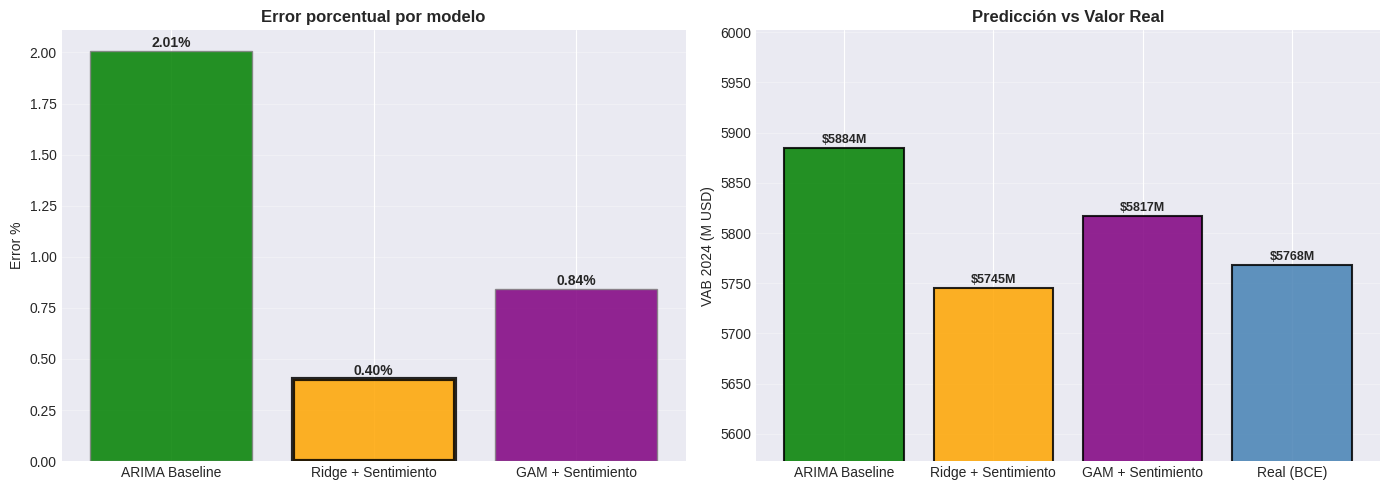

In [ ]:
# =================================================================
# BLOQUE 10 (NUEVO): VALIDACIÓN CON VAB REAL 2024
# =================================================================

print("\n" + "=" * 70)
print("VALIDACIÓN CON VAB REAL 2024 — TRES MODELOS")
print("=" * 70)

vab_real_2024 = 5768.4  # Millones USD (BCE)

vab_2023_ref = df_vab_calibracion[df_vab_calibracion['año']==2023]['vab_corriente'].values[0]
tasa_var_real = ((vab_real_2024 - vab_2023_ref) / vab_2023_ref) * 100

print(f"\nVAB Real 2024 (BCE): ${vab_real_2024:.2f}M")
print(f"Variación real vs 2023: {tasa_var_real:+.2f}%")

resultados = []

if prediccion_vab_2024_arima:
    e_arima = abs(prediccion_vab_2024_arima - vab_real_2024)
    resultados.append({
        'Modelo':      'ARIMA Baseline',
        'Predicción':  prediccion_vab_2024_arima,
        'Error Abs':   e_arima,
        'Error %':     (e_arima / vab_real_2024) * 100,
        'color':       'green'
    })

if vab_2024_sentimiento:
    e_ridge = abs(vab_2024_sentimiento - vab_real_2024)
    resultados.append({
        'Modelo':      'Ridge + Sentimiento',
        'Predicción':  vab_2024_sentimiento,
        'Error Abs':   e_ridge,
        'Error %':     (e_ridge / vab_real_2024) * 100,
        'color':       'orange'
    })

if vab_2024_gam:
    e_gam = abs(vab_2024_gam - vab_real_2024)
    resultados.append({
        'Modelo':      'GAM + Sentimiento',
        'Predicción':  vab_2024_gam,
        'Error Abs':   e_gam,
        'Error %':     (e_gam / vab_real_2024) * 100,
        'color':       'purple'
    })

print("\nResultados de validación:")
print("=" * 80)
print(f"  {'Modelo':<30} {'Predicción':>12}  {'Error Abs':>12}  {'Error %':>10}")
print("=" * 80)
print(f"  {'Real 2024':<30} ${vab_real_2024:>11.2f}  {'—':>12}  {'—':>10}")
for r in resultados:
    print(f"  {r['Modelo']:<30} ${r['Predicción']:>11.2f}  ${r['Error Abs']:>11.2f}  {r['Error %']:>9.2f}%")
print("=" * 80)

# Ganador
if resultados:
    mejor = min(resultados, key=lambda x: x['Error %'])
    print(f"\nMejor modelo: {mejor['Modelo']} (error {mejor['Error %']:.2f}%)")

    if len(resultados) > 1:
        baseline = next(r for r in resultados if r['Modelo'] == 'ARIMA Baseline')
        for r in resultados:
            if r['Modelo'] != 'ARIMA Baseline':
                mejora = ((baseline['Error Abs'] - r['Error Abs']) / baseline['Error Abs']) * 100
                print(f"  {r['Modelo']}: {mejora:+.1f}% vs ARIMA")

# Gráfico de errores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres  = [r['Modelo'] for r in resultados]
errores  = [r['Error %'] for r in resultados]
colores  = [r['color'] for r in resultados]
min_err  = min(errores)
edge_col = ['black' if e == min_err else 'gray' for e in errores]
lws      = [3 if e == min_err else 1 for e in errores]

axes[0].bar(nombres, errores, color=colores, alpha=0.85,
            edgecolor=edge_col, linewidth=lws)
axes[0].set_title('Error porcentual por modelo', fontweight='bold')
axes[0].set_ylabel('Error %')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(errores):
    axes[0].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontweight='bold')

preds = [r['Predicción'] for r in resultados] + [vab_real_2024]
noms  = [r['Modelo'] for r in resultados] + ['Real (BCE)']
cols2 = [r['color'] for r in resultados] + ['steelblue']
axes[1].bar(noms, preds, color=cols2, alpha=0.85, edgecolor='black', linewidth=1.5)
axes[1].set_title('Predicción vs Valor Real', fontweight='bold')
axes[1].set_ylabel('VAB 2024 (M USD)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(min(preds)*0.97, max(preds)*1.02)
for i, v in enumerate(preds):
    axes[1].text(i, v + 5, f'${v:.0f}M', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
